# Notebook 02: Preprocesamiento
## 2. Preprocesamiento


**Objetivo**: Preparar la muestra de desarrollo a partir del dataset limpio generado en el notebook 01.

Pasos:
1. Oversampling estratificado 1:2 para corregir el desbalanceo.
2. Partición estratificada train / validación / test (50% / 25% / 25%).

**Entrada**: *data/01_dataset_limpio.csv*, 73.210 obs x 31 columnas (25 predictoras + 5 Flags + Target_Impago).  
**Salidas**: *data/train.csv*, *data/val.csv*, *data/test.csv*.


## 2.1 Importaciones


Se importan las librerías necesarias y se establece la semilla de aleatoriedad para garantizar la reproducibilidad de todos los muestreos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
sns.set_style('whitegrid')
print('Librerías importadas correctamente.')


Librerías importadas correctamente.


## 2.2 Carga del dataset procesado (salida del notebook 01)

El punto de partida de este notebook es el fichero que dejó preparado el análisis exploratorio. En el notebook 01 ya se trataron los valores ausentes, se crearon los Flags y se obtuvo un dataset limpio y sin nulos. Para no rehacer ese trabajo, aquí se carga directamente ese resultado y, antes de seguir, se comprueba que las proporciones de buenos y malos se mantienen tal como las dejó el EDA.

In [2]:
df = pd.read_csv('../data/01_dataset_limpio.csv')

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Buenos (0): {(df.Target_Impago==0).sum():,} ({(df.Target_Impago==0).mean():.1%})')
print(f'Malos  (1): {(df.Target_Impago==1).sum():,} ({(df.Target_Impago==1).mean():.1%})')


Dimensiones: 73,210 filas x 31 columnas
Buenos (0): 67,701 (92.5%)
Malos  (1): 5,509 (7.5%)


## 2.3 Oversampling estratificado: réplica del método de Mallo

### El problema: un desbalanceo extremo

El dataset completo tiene 73.210 clientes, de los cuales solo el 7.5% son malos pagadores. Esta escasez de impagos dificulta el aprendizaje: un modelo entrenado directamente sobre estos datos tiende a clasificar a todos los clientes como buenos pagadores, ya que con ello alcanza una precisión global del 92.5% sin necesidad de discriminar entre clases. El resultado es un modelo con una exactitud aparentemente alta pero inútil en la práctica, porque falla precisamente en su cometido: identificar a los clientes que van a impagar.

### La solución: una muestra de desarrollo equilibrada

La estrategia adoptada, que replica la empleada por Fernando Mallo, consiste en construir una muestra de entrenamiento equilibrada en la que los malos pagadores tengan presencia suficiente para que el modelo aprenda a identificarlos. Dicha muestra se compone según dos criterios:

1. **Todos los malos** (5.509): se incorporan en su totalidad, dado que constituyen el evento minoritario y no resulta admisible descartar ninguna de estas observaciones.
2. **Una submuestra de buenos** (11.283): se seleccionan aleatoriamente de entre los 67.701 disponibles, los necesarios para establecer una proporción de 1 malo por cada 2 buenos.

La muestra resultante consta de **16.792 observaciones**, con un 32.8% de malos. Frente al 7.5% original, esta composición aporta al modelo información suficiente para discriminar entre ambas clases.

### Por qué hace falta corregir con un peso

El equilibrado resuelve el problema del desbalanceo, pero introduce uno nuevo. De los 67.701 buenos reales solo se conservan 11.283 en la muestra; los 56.418 restantes quedan fuera del entrenamiento. Como consecuencia, la proporción de malos en los datos de entrenamiento asciende al 32.8%, muy por encima del 7.5% que se observa en la población real.

Si no se corrigiera esta distorsión, el modelo asumiría que el impago es mucho más frecuente de lo que realmente es y asignaría a cada nuevo solicitante una probabilidad de impago inflada, lo que volvería las decisiones de concesión excesivamente conservadoras.

### Cómo se calcula y se aplica el peso

La corrección consiste en asignar a cada cliente bueno de la muestra un peso que compense a los que quedaron excluidos. Dado que se ha conservado uno de cada seis buenos (el cociente entre 67.701 y 11.283 es aproximadamente 6), cada observación buena debe contar como si representara a seis clientes. Ese factor, igual a 6, es el peso aplicado.

En la práctica, el peso se transmite al modelo mediante el argumento *sample_weight*: durante el ajuste, cada observación buena contribuye seis veces más que una mala al cálculo de la función de pérdida. El resultado es estadísticamente equivalente a entrenar sobre los 67.701 buenos reales, sin necesidad de duplicar físicamente esas filas en el dataset.

De este modo se concilian dos objetivos. La muestra equilibrada proporciona al modelo un número suficiente de malos para aprender a discriminarlos, mientras que el peso garantiza que las probabilidades de impago estimadas se ajusten a las proporciones reales de la población (el 7.5%) y no a las de la muestra (el 32.8%). Este mismo peso se aplica de forma idéntica a los tres modelos: Regresión Logística, Random Forest y XGBoost.

A continuación se aplica el sobremuestreo estratificado: se seleccionan todos los malos y una submuestra aleatoria de buenos en proporción 1:2, y se calcula el peso corrector.

In [3]:
N_MALOS  = 5509
N_BUENOS = 11283
PESO = round(len(df[df.Target_Impago == 0]) / N_BUENOS, 2)

df_malos  = df[df.Target_Impago == 1]
df_buenos = df[df.Target_Impago == 0]

df_buenos_sample = df_buenos.sample(n=N_BUENOS, random_state=SEED)
df_sample = pd.concat([df_malos, df_buenos_sample], ignore_index=True)

print(f'Muestra de desarrollo (réplica Mallo):')
print(f'  Total:          {len(df_sample):,} observaciones')
print(f'  Malos  (1):     {(df_sample.Target_Impago==1).sum():,} ({(df_sample.Target_Impago==1).mean():.1%})')
print(f'  Buenos (0):     {(df_sample.Target_Impago==0).sum():,} ({(df_sample.Target_Impago==0).mean():.1%})')
print(f'  Peso aplicado:  {PESO}')


Muestra de desarrollo (réplica Mallo):
  Total:          16,792 observaciones
  Malos  (1):     5,509 (32.8%)
  Buenos (0):     11,283 (67.2%)
  Peso aplicado:  6.0


El gráfico que ilustra esta redistribución compara la proporción de buenos y malos antes y después del oversampling, mostrando el efecto del equilibrado sobre la muestra de desarrollo.

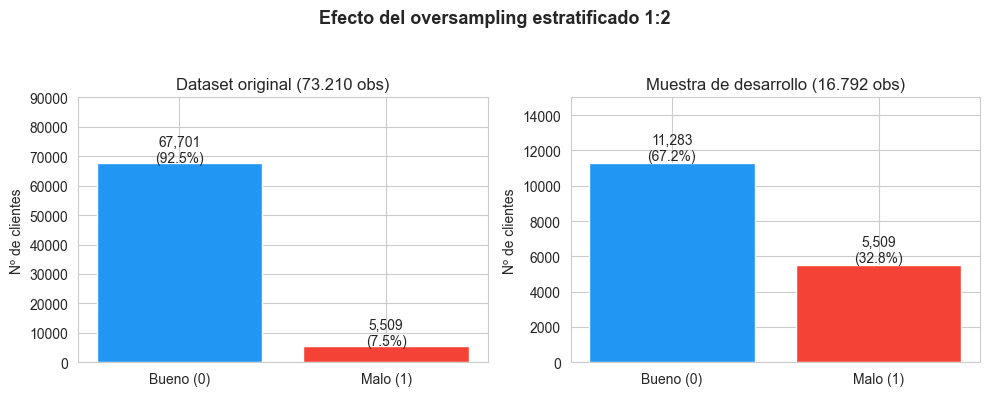

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Dataset original
conteo_orig = df['Target_Impago'].value_counts().sort_index()
axes[0].bar(['Bueno (0)', 'Malo (1)'], conteo_orig.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Dataset original (73.210 obs)')
axes[0].set_ylabel('Nº de clientes')
axes[0].set_ylim(0, 90000)
for bar, v in zip(axes[0].patches, conteo_orig.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)

# Muestra oversampling
conteo_samp = df_sample['Target_Impago'].value_counts().sort_index()
axes[1].bar(['Bueno (0)', 'Malo (1)'], conteo_samp.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[1].set_title('Muestra de desarrollo (16.792 obs)')
axes[1].set_ylabel('Nº de clientes')
axes[1].set_ylim(0, 15000)
for bar, v in zip(axes[1].patches, conteo_samp.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{v:,}\n({v/len(df_sample):.1%})', ha='center', fontsize=10)

plt.suptitle('Efecto del oversampling estratificado 1:2', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../reports/figures/02_oversampling_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

La comparación evidencia el efecto del oversampling. En el dataset original (izquierda) los malos apenas representan el 7.5% del total, mientras que en la muestra de desarrollo (derecha) su peso se eleva hasta el 32.8%. Conviene observar que el número absoluto de malos es idéntico en ambos casos (5.509): no se ha generado ningún impago nuevo, sino que se ha reducido la submuestra de buenos para alcanzar la proporción 1:2 deseada.

## 2.4 Partición train / validación / test (50% / 25% / 25%)

### Por qué se divide la muestra

Una vez equilibrada la muestra de desarrollo, debe repartirse en subconjuntos independientes antes de entrenar ningún modelo. El motivo es que el rendimiento de un modelo de scoring, y de cualquier modelo de machine learning en general, debe medirse sobre su capacidad de generalización, esto es, sobre los casos de los cleintes que no se han tenido en cuenta en la etapa de aprendizaje. Evaluar el modelo sobre los mismos datos con los que se ajustó produciría una estimación sesgada al alza, ya que reconocería patrones que ha memorizado y no necesariamente regularidades extrapolables a casos nuevos.

Por este motivo la muestra se divide en tres subconjuntos con funciones diferenciadas: un conjunto de **entrenamiento**, sobre el que el modelo estima sus parámetros; un conjunto de **validación**, empleado para comparar entre sí los tres modelos que se desarrollarán en este estudio (la Regresión Logística que sirve de referencia y los modelos de machine learning Random Forest y XGBoost) y ajustar sus hiperparámetros; y un conjunto de **test**, reservado para la evaluación final sobre datos que no han intervenido en ninguna fase previa.

### Tamaño de cada conjunto

La muestra de 16.792 observaciones se reparte de la siguiente manera:

| Conjunto | Tamaño | Función |
|----------|--------|---------|
| Train | 50% (~8.396 obs) | El modelo aprende aquí: estima coeficientes y construye árboles |
| Validación | 25% (~4.198 obs) | Comparar los tres modelos entre sí y ajustar sus hiperparámetros |
| Test | 25% (~4.198 obs) | Métricas finales sobre datos nunca vistos; es lo que se compara con Mallo |

### La estratificación

El reparto no se realiza de forma puramente aleatoria. Al igual que en el sobremuestreo se controla la proporción de buenos y malos, conviene que los tres conjuntos conserven el mismo 32.8% de malos de la muestra de desarrollo. De lo contrario, la aleatoriedad podría concentrar los impagos de manera desigual y comprometer la representatividad de cada subconjunto. El parámetro *stratify=y* de *train_test_split* mantiene esa proporción en cada bloque de forma automática.

### La partición reproduce la del estudio de referencia

El reparto 50% / 25% / 25% reproduce el que empleó Fernando Mallo en el estudio de referencia. Sobre la muestra de desarrollo de 16.792 observaciones, asigna unas 8.396 observaciones al entrenamiento y 4.198 a cada uno de los conjuntos de validación y test. Reservar la mitad de la muestra al entrenamiento resulta, además, conveniente para los modelos no lineales incorporados en este trabajo, Random Forest y XGBoost, que requieren un volumen de datos suficiente para un ajuste adecuado, sin que ello comprometa la estabilidad de las métricas estimadas sobre validación y test. La versión doctoral del estudio (Mallo, 2011) empleó, en cambio, un reparto 40% / 30% / 30%.

A continuación se realiza la partición estratificada en dos pasos: primero se separa el 50% para train, y el 50% restante se divide a la mitad en validación y test.

In [5]:
FEATURES = [c for c in df_sample.columns if c != 'Target_Impago']
X = df_sample[FEATURES]
y = df_sample['Target_Impago']

# 50% train / 50% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=SEED, stratify=y
)
# 50% temp → 25% val / 25% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print('Particiones:')
print(f'  Train:      {len(X_train):,} obs ({len(X_train)/len(df_sample):.0%}) | malos: {y_train.mean():.1%}')
print(f'  Validación: {len(X_val):,} obs ({len(X_val)/len(df_sample):.0%}) | malos: {y_val.mean():.1%}')
print(f'  Test:       {len(X_test):,} obs ({len(X_test)/len(df_sample):.0%}) | malos: {y_test.mean():.1%}')
print(f'  Features usadas: {len(FEATURES)}')


Particiones:
  Train:      8,396 obs (50%) | malos: 32.8%
  Validación: 4,198 obs (25%) | malos: 32.8%
  Test:       4,198 obs (25%) | malos: 32.8%
  Features usadas: 30


## 2.5 Guardar las particiones

Para que los notebooks de modelización y evaluación no tengan que repetir todo este proceso, los tres conjuntos se guardan en disco. A partir de aquí, el 03 y el 04 solo necesitarán cargarlos.

In [6]:
X_train.assign(Target_Impago=y_train).to_csv('../data/train.csv', index=False)
X_val.assign(Target_Impago=y_val).to_csv('../data/val.csv',   index=False)
X_test.assign(Target_Impago=y_test).to_csv('../data/test.csv',  index=False)

print('Particiones guardadas:')
print(f'  data/train.csv   ({len(X_train):,} obs)')
print(f'  data/val.csv     ({len(X_val):,} obs)')
print(f'  data/test.csv    ({len(X_test):,} obs)')


Particiones guardadas:
  data/train.csv   (8,396 obs)
  data/val.csv     (4,198 obs)
  data/test.csv    (4,198 obs)


## 2.6 Resumen del preprocesamiento

A lo largo de este notebook, el dataset limpio procedente del EDA se ha transformado en una muestra de desarrollo equilibrada y dividida en los tres subconjuntos necesarios para el modelado. La siguiente tabla recoge las decisiones adoptadas y las contrasta con las del estudio de referencia de Mallo:

| Paso | Nuestro estudio | Mallo (referencia) |
|------|-----------------|--------------------|
| Dataset de partida | 73.210 obs, 30 predictoras (25 originales + 5 Flags) | 73.210 obs, 25 predictoras |
| Tratamiento nulos | Flags + imputación a 0 | WoE-binning (_W) |
| Oversampling | 16.792 obs (5.509 + 11.283), peso=6 | Igual |
| Partición | 50% / 25% / 25% | Igual |
| Train / Validación / Test | ~8.396 / ~4.198 / ~4.198 | Igual |

Este trabajo parte de las mismas 25 variables predictoras que Mallo. La diferencia en el número de predictoras (30 frente a 25) se debe exclusivamente a los 5 Flags de ausencia añadidos en el notebook 01 como parte del Feature Engineering.

El preprocesamiento reproduce fielmente el del estudio de referencia: mismo dataset de partida, mismo oversampling (16.792 observaciones, proporción de un malo por cada dos buenos y peso corrector 6) e idéntica partición 50% / 25% / 25%. La única diferencia metodológica reside en el tratamiento de los valores ausentes, abordado en este trabajo con variables indicadoras (Flags) e imputación a cero en lugar de la transformación WoE empleada por Mallo.

El resultado del notebook son tres ficheros independientes (*train.csv*, *val.csv* y *test.csv*), que constituyen el punto de partida de la modelización en el **notebook 03**.